In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

# Physics Constraint Comparison: Burgers Equation

- PDE: $\partial_t u + u \partial_x u = \frac{0.1}{\pi} \partial_{xx} u$
- Unknown: initial condition $a(x) = u(x, t=0)$
- Latent dimension: $d = 16$
- Physics term: weak PDE residual at fixed space-time collocation points

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

from src.problems.burgers import (
    Burgers,
    mollifier_burgers,
    compute_pde_residual_single_sample_burgers,
)
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    compute_prior_predictive, build_prior_result,
    plot_posterior_predictive, plot_trace,
    plot_rho_sweep, plot_sharpness_calibration_tradeoff,
    plot_metrics_comparison_table, plot_calibration_overlay,
    bootstrap_metric_ci, compute_per_chain_metrics,
    bootstrap_metric_difference_ci, format_significance_table,
    plot_burgers_field_comparison, plot_burgers_std_comparison,
    plot_burgers_posterior_gallery,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model, make_numpyro_model_physics,
    run_map_estimation, compute_sigma_from_map_residual,
    sample_unconditional_prior,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics, compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
    compute_error_std_correlation,
    load_cross_seed_results, cross_seed_metric_summary,
    decode_initial_condition_burgers,
    _use_science_style,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_burgers/weights/best.pt")
TEST_DATA_PATH = "../data/burgers/viscid_test_in.mat"

problem = Burgers(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()
x_mesh = problem.x_mesh
t_mesh = problem.t_mesh

print(f"Latent dim: {problem.BETA_SIZE}")
print(f"n_mesh: {problem.n_mesh}, n_time: {problem.n_time}")

Loading data...
  Test: a=(200, 128, 1), u=(200, 12928, 1)
Setting up grids and test functions...


  int_grid: (10, 1), v: (10, 1)
Building models...


  Initialized enc: 25,808 params


  Initialized u: 103,006 params


  Initialized nf: 60,480 params
Loading checkpoint: ../runs/final_burgers/weights/best.pt
  Loaded enc
  Loaded u
  Loaded nf


Latent dim: 16
n_mesh: 128, n_time: 101


## 2. Config

In [4]:
N_OBS = 100
NC_PDE = 50

RHO_PDE_VALUES = [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]
SWEEP_WARMUP = 1000
SWEEP_SAMPLES = 500

# NUM_SAMPLES=3000 here (vs 2000 in other scripts) is deliberate: Burgers'
# 16-dim space benefits from more samples for better ESS estimates.
NUM_WARMUP = 5000
NUM_SAMPLES = 3000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

inv_config = InversionConfig(
    epochs=500,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=100, gamma=0.8),
)

## 3. Burgers-Specific Decode Functions

In [5]:
def decode_solution_batched(beta_samples, x_full, batch_size=500):
    """Decode beta samples to full space-time solution, in batches."""
    n_s = beta_samples.shape[0]
    parts = []
    for i in range(0, n_s, batch_size):
        b = beta_samples[i:i + batch_size]
        xt = jnp.tile(x_full, (b.shape[0], 1, 1))
        u_raw = problem.models['u'].apply({'params': params['u']}, xt, b)
        if u_raw.ndim == 3:
            u_raw = u_raw.squeeze(-1)
        parts.append(mollifier_burgers(u_raw, xt))
    return jnp.concatenate(parts, axis=0)

## 4. Fixed PDE Collocation Points

In [6]:
# Point1DTime.weight_centers returns 3 values (xc, tc, R)
pde_rng = random.PRNGKey(123)
xc_fixed, tc_fixed, R_fixed = problem.genPoint.weight_centers(
    n_center=NC_PDE, R_max=1e-4, R_min=1e-4, key=pde_rng,
)

print(f"Fixed PDE collocation: {NC_PDE} space-time centers")


def log_pde_fn(beta, rho_pde):
    """PDE virtual-observable log-likelihood for Burgers."""
    residuals = compute_pde_residual_single_sample_burgers(
        params['u'], problem.models['u'], beta,
        xc_fixed, tc_fixed, R_fixed,
        problem.int_grid, problem.v, problem.dv_dr,
        problem.n_grid, problem.LAMDA,
    )
    return -0.5 * jnp.sum(residuals ** 2) / (rho_pde ** 2)

Fixed PDE collocation: 50 space-time centers


## 5. Sigma (tune_sigma, seed-42 observations)

In [7]:
_rng_setup = random.PRNGKey(42)
_rng_setup, _key = random.split(_rng_setup)

_obs_indices_tune = problem.sample_observation_indices(n_points, N_OBS, 'random', _key)
_obs_data_tune = problem.prepare_observations(
    sample_indices=[TEST_IDX], obs_indices=_obs_indices_tune,
)
_x_full_tune = _obs_data_tune['x_full']
_x_obs_tune = _obs_data_tune['x_obs']
_u_obs_tune = _obs_data_tune['u_obs']
_a_true_tune = _obs_data_tune['a_true']

_log_lik_tune = make_gaussian_log_likelihood(problem, params, mollifier_burgers, _x_obs_tune, _u_obs_tune)
_numpyro_model_tune = make_numpyro_model(d, log_prior_fn, _log_lik_tune)

SIGMA_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01]
_nuts_cfg_tune = recommended_nuts_config(problem.BETA_SIZE, sigma=0.005)


def _model_factory_tune(sigma):
    def _model():
        _numpyro_model_tune(sigma=sigma)
    return _model


def _decode_fn_tune(beta_samples):
    return decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_samples)


_rng_setup, _tune_key = random.split(_rng_setup)
SIGMA, _ = tune_sigma(
    model_fn_factory=_model_factory_tune,
    beta_mode=beta_mode,
    sigma_candidates=SIGMA_CANDIDATES,
    rng_key=_tune_key,
    decode_fn=_decode_fn_tune,
    a_true=np.array(_a_true_tune[0, :, 0]),
    target_accept_prob=_nuts_cfg_tune['target_accept_prob'],
)
print(f"Sigma (tuned, seed-42): {SIGMA:.6f}")

  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.0010  cov=0.656  ESS_min=362.6  R-hat=1.005  div=0  OK


    sigma=0.0020  cov=0.844  ESS_min=468.5  R-hat=1.003  div=0  OK


    sigma=0.0030  cov=0.883  ESS_min=448.4  R-hat=1.005  div=0  OK


    sigma=0.0050  cov=0.945  ESS_min=452.3  R-hat=1.011  div=0  OK


    sigma=0.0070  cov=0.945  ESS_min=658.1  R-hat=1.003  div=0  OK


    sigma=0.0100  cov=0.977  ESS_min=480.0  R-hat=1.004  div=0  OK
  Selected sigma=0.005  (coverage=0.945, ESS_min=452.3)
Sigma (tuned, seed-42): 0.005000


## 6. rho_pde Sweep (outside seed loop)

In [8]:
_numpyro_model_physics_sweep = make_numpyro_model_physics(d, log_prior_fn, _log_lik_tune, log_pde_fn)

# Data-only sweep baseline
_rng_setup, _sweep_do_key = random.split(_rng_setup)
nuts_cfg_sweep = recommended_nuts_config(problem.BETA_SIZE, SIGMA)
_kernel_sweep_do = NUTS(
    _numpyro_model_tune,
    init_strategy=init_to_value(values={"beta": beta_mode}),
    target_accept_prob=nuts_cfg_sweep['target_accept_prob'],
    max_tree_depth=nuts_cfg_sweep['max_tree_depth'],
)
_mcmc_sweep_do = MCMC(_kernel_sweep_do, num_warmup=SWEEP_WARMUP, num_samples=SWEEP_SAMPLES,
                      num_chains=1, progress_bar=True)
_mcmc_sweep_do.run(_sweep_do_key, sigma=SIGMA, extra_fields=('diverging',))

_beta_sweep_do = _mcmc_sweep_do.get_samples()["beta"]
_a_pred_sweep_do = decode_initial_condition_burgers(problem, params, mollifier_burgers, _beta_sweep_do)
_a_mean_sweep_do = jnp.mean(_a_pred_sweep_do, axis=0)
_a_err_sweep_do = float(
    jnp.linalg.norm(_a_mean_sweep_do - _a_true_tune[0, :, 0]) /
    jnp.linalg.norm(_a_true_tune[0, :, 0])
)
_a_lo_sweep_do = jnp.percentile(_a_pred_sweep_do, 2.5, axis=0)
_a_hi_sweep_do = jnp.percentile(_a_pred_sweep_do, 97.5, axis=0)
_coverage_sweep_do = float(((jnp.array(_a_true_tune[0, :, 0]) >= _a_lo_sweep_do) & (jnp.array(_a_true_tune[0, :, 0]) <= _a_hi_sweep_do)).mean())
_ci_width_sweep_do = float(jnp.mean(_a_hi_sweep_do - _a_lo_sweep_do))
_mean_std_sweep_do = float(jnp.mean(jnp.std(_a_pred_sweep_do, axis=0)))
_sweep_data_only_baseline = {
    'a_err': _a_err_sweep_do,
    'coverage': _coverage_sweep_do,
    'ci_width': _ci_width_sweep_do,
    'mean_std': _mean_std_sweep_do,
}
print(f"Sweep data-only baseline a_err = {_a_err_sweep_do:.4f}")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:04<2:02:30,  4.90s/it, 1 steps of size 2.13e+00. acc. prob=0.00]

warmup:   1%|          | 13/1500 [00:05<06:56,  3.57it/s, 95 steps of size 7.01e-04. acc. prob=0.62]

warmup:   1%|▏         | 19/1500 [00:05<04:37,  5.35it/s, 9 steps of size 6.76e-04. acc. prob=0.68] 

warmup:   2%|▏         | 24/1500 [00:05<03:34,  6.88it/s, 63 steps of size 3.48e-03. acc. prob=0.73]

...

sample:  99%|█████████▉| 1490/1500 [00:55<00:00, 31.12it/s, 31 steps of size 9.83e-02. acc. prob=0.94]

sample: 100%|█████████▉| 1494/1500 [00:55<00:00, 30.48it/s, 63 steps of size 9.83e-02. acc. prob=0.94]

sample: 100%|█████████▉| 1498/1500 [00:55<00:00, 28.62it/s, 63 steps of size 9.83e-02. acc. prob=0.94]

sample: 100%|██████████| 1500/1500 [00:55<00:00, 26.88it/s, 63 steps of size 9.83e-02. acc. prob=0.94]

Sweep data-only baseline a_err = 0.1768


In [9]:
def _run_sweep_one(rho_pde, warmup, n_samples, rng_key):
    """Run NUTS for one rho_pde value (using tuning obs), return metrics dict."""
    nuts_cfg = recommended_nuts_config(problem.BETA_SIZE, SIGMA)
    kernel = NUTS(
        _numpyro_model_physics_sweep,
        init_strategy=init_to_value(values={"beta": beta_mode}),
        target_accept_prob=nuts_cfg['target_accept_prob'],
        max_tree_depth=nuts_cfg['max_tree_depth'],
    )
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=n_samples,
                num_chains=1, chain_method=CHAIN_METHOD, progress_bar=True)
    _t_pilot = time.time()
    mcmc.run(rng_key, sigma=SIGMA, rho_pde=rho_pde, extra_fields=('diverging',))
    print(f"  Pilot completed in {time.time() - _t_pilot:.1f}s")

    beta_s = mcmc.get_samples()["beta"]
    n_div = int(mcmc.get_extra_fields()['diverging'].sum())

    beta_by_chain = np.array(beta_s)[None, :, :]
    ess_min = float(effective_sample_size(beta_by_chain).min())

    _a_true_np_t = np.array(_a_true_tune[0, :, 0])
    a_pred = decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_s)
    a_mean = jnp.mean(a_pred, axis=0)
    a_err = float(jnp.linalg.norm(a_mean - _a_true_tune[0, :, 0]) / jnp.linalg.norm(_a_true_tune[0, :, 0]))

    a_samples_np = np.array(a_pred)
    metrics = compute_standard_metrics(a_samples_np, _a_true_np_t)
    flag, _ = mcmc_reliability_flag(ess_min, 1.0, n_div, n_samples)

    return {
        "rho_pde": rho_pde,
        "a_err": a_err,
        "u_err": 0.0,
        "coverage": metrics['coverage_95'],
        "ess_min": ess_min,
        "n_div": n_div,
        "crps_a": metrics['crps_a'],
        "nll_a": metrics['nll_a'],
        "ci_width": metrics['ci_width'],
        "mean_std": metrics['mean_std'],
        "rhat_max": None,
        "rhat_mean": None,
        "reliability_flag": flag,
    }

In [10]:
print(f"Screening sweep: {SWEEP_WARMUP} warmup, {SWEEP_SAMPLES} samples per rho")
print(f"rho values: {RHO_PDE_VALUES}")

sweep_results = []
for rho in RHO_PDE_VALUES:
    print(f"\n{'='*60}")
    print(f"rho_pde = {rho}")
    print(f"{'='*60}")
    _rng_setup, key = random.split(_rng_setup)
    res = _run_sweep_one(rho, SWEEP_WARMUP, SWEEP_SAMPLES, key)
    sweep_results.append(res)
    print(f"  a_err={res['a_err']:.4f}  "
          f"coverage={res['coverage']:.2%}  ESS_min={res['ess_min']:.1f}  "
          f"n_div={res['n_div']}  CRPS_a={res['crps_a']:.6f}")

Screening sweep: 1000 warmup, 500 samples per rho
rho values: [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]

rho_pde = 2.0


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:06<2:36:44,  6.27s/it, 1 steps of size 2.13e+00. acc. prob=0.00]

warmup:   1%|          | 13/1500 [00:06<09:08,  2.71it/s, 255 steps of size 7.03e-04. acc. prob=0.62]

warmup:   1%|          | 16/1500 [00:06<07:25,  3.33it/s, 63 steps of size 3.21e-03. acc. prob=0.69] 

...

sample: 100%|█████████▉| 1493/1500 [01:14<00:00, 21.25it/s, 31 steps of size 9.17e-02. acc. prob=0.95]

sample: 100%|█████████▉| 1496/1500 [01:14<00:00, 20.88it/s, 31 steps of size 9.17e-02. acc. prob=0.95]

sample: 100%|█████████▉| 1499/1500 [01:14<00:00, 21.95it/s, 31 steps of size 9.17e-02. acc. prob=0.95]

sample: 100%|██████████| 1500/1500 [01:14<00:00, 20.14it/s, 63 steps of size 9.17e-02. acc. prob=0.95]

  Pilot completed in 75.2s
  a_err=0.1720  coverage=92.97%  ESS_min=315.7  n_div=0  CRPS_a=0.008541


In [11]:
header = f"{'rho_pde':>10} {'a_err':>8} {'coverage':>10} {'ESS_min':>9} {'n_div':>6} {'CRPS_a':>10}"
print(header)
print("-" * len(header))
print(f"{'inf (DO)':>10}  {_a_err_sweep_do:>7.4f}  {'N/A':>9}  {'N/A':>8}  {'N/A':>5}  {'N/A':>9}")
for r in sweep_results:
    print(f"{r['rho_pde']:>10.2f}  {r['a_err']:>7.4f}  "
          f"{r['coverage']:>9.2%}  {r['ess_min']:>8.1f}  {r['n_div']:>5}  {r['crps_a']:>9.6f}")

   rho_pde    a_err   coverage   ESS_min  n_div     CRPS_a
----------------------------------------------------------
  inf (DO)   0.1768        N/A       N/A    N/A        N/A
      2.00   0.1683     92.97%     230.9      0   0.008357
      1.00   0.1699     92.19%     192.0      0   0.008397
      0.50   0.1741     92.97%     241.2      0   0.008677
      0.30   0.1685     94.53%     164.5      0   0.008330
      0.15   0.1710     89.84%     282.7      0   0.008516
      0.10   0.1713     91.41%     205.5      0   0.008537
      0.07   0.1672     94.53%     225.9      0   0.008257
      0.05   0.1720     92.97%     315.7      0   0.008541


In [12]:
_a_err_threshold = _a_err_sweep_do * 2
candidates = [(abs(r['coverage'] - 0.95), r) for r in sweep_results
              if r['a_err'] <= _a_err_threshold]

if candidates:
    candidates.sort(key=lambda x: x[0])
    _best = candidates[0][1]
    BEST_RHO_PDE = _best['rho_pde']
    print(f"Best rho_pde = {BEST_RHO_PDE}")
    print(f"  a_err    = {_best['a_err']:.4f}  (baseline: {_a_err_sweep_do:.4f})")
    print(f"  coverage = {_best['coverage']:.2%}  (ideal: 95%)")
else:
    print("No candidate with a_err <= 2x baseline.")
    print("Setting BEST_RHO_PDE to largest value (weakest physics).")
    BEST_RHO_PDE = max(RHO_PDE_VALUES)

print(f"\nBEST_RHO_PDE = {BEST_RHO_PDE}")

Best rho_pde = 0.3
  a_err    = 0.1685  (baseline: 0.1768)
  coverage = 94.53%  (ideal: 95%)

BEST_RHO_PDE = 0.3


## 7. Multi-Seed Loop


SEED = 7


Prior predictive: a_err=1.0368, CRPS=0.0537, cov95=0.9922


  Inversion grid: n_mesh_or_grid=7, n_grid=7


Loss weights: pde=1.0, data=50.0, target=u


Inverting:   0%|          | 0/500 [00:00<?, ?it/s]

...

sample: 100%|██████████| 3000/3000 [03:09<00:00, 15.86it/s]

MCMC warmup: 317.5s, sampling: 189.1s
ESS min=8733.0, R-hat max=1.0005, divergences=0/12000, [PASS] All diagnostics within thresholds


Physics: a_err=0.1826  u_err=0.0324  coverage=96.09%  CRPS=0.008873


  Chi2 PPC (data-only): chi2=0.49, p=1.0000
  Chi2 PPC (physics):   chi2=0.48, p=1.0000
Saved structured result to: /workspace/experiments/results/structured/physics/burgers_2026-06-12T13-30-08_seed7_test2.json

  Burgers seed=7 (sigma=0.01, rho_pde=0.3)
  Metric                           Data-Only      Physics-Inf
  -----------------------------------------------------------
  RMSE (a)                          0.181769         0.182618
  Rel. L2 (a)                       0.181769         0.182618
  Rel. L2 (u)                       0.032191         0.032434
  CRPS (a)                          0.008811         0.008873
  95% Coverage                      0.960938         0.960938
  CI Width (a)                      0.066894         0.067421
  Sharpness (mean std)              0.017073         0.017191
  ESS min                        9180.553240      8732.978881
  Divergences                              0                0



──────────────────────────────────────────────────────────────────────────────────
  Burgers seed=7 -- RQ2: Physics vs Data-Only (Bootstrap)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a) diff (DO - Phys)               diff=-0.00006  CI [-0.00012, +0.00000]  n.s.
  Coverage 95% diff (DO - Phys)           diff=+0.00000  CI [+0.00000, +0.00000]  n.s.
  CI Width diff (DO - Phys)               diff=-0.00053  CI [-0.00098, -0.00006]  *
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────


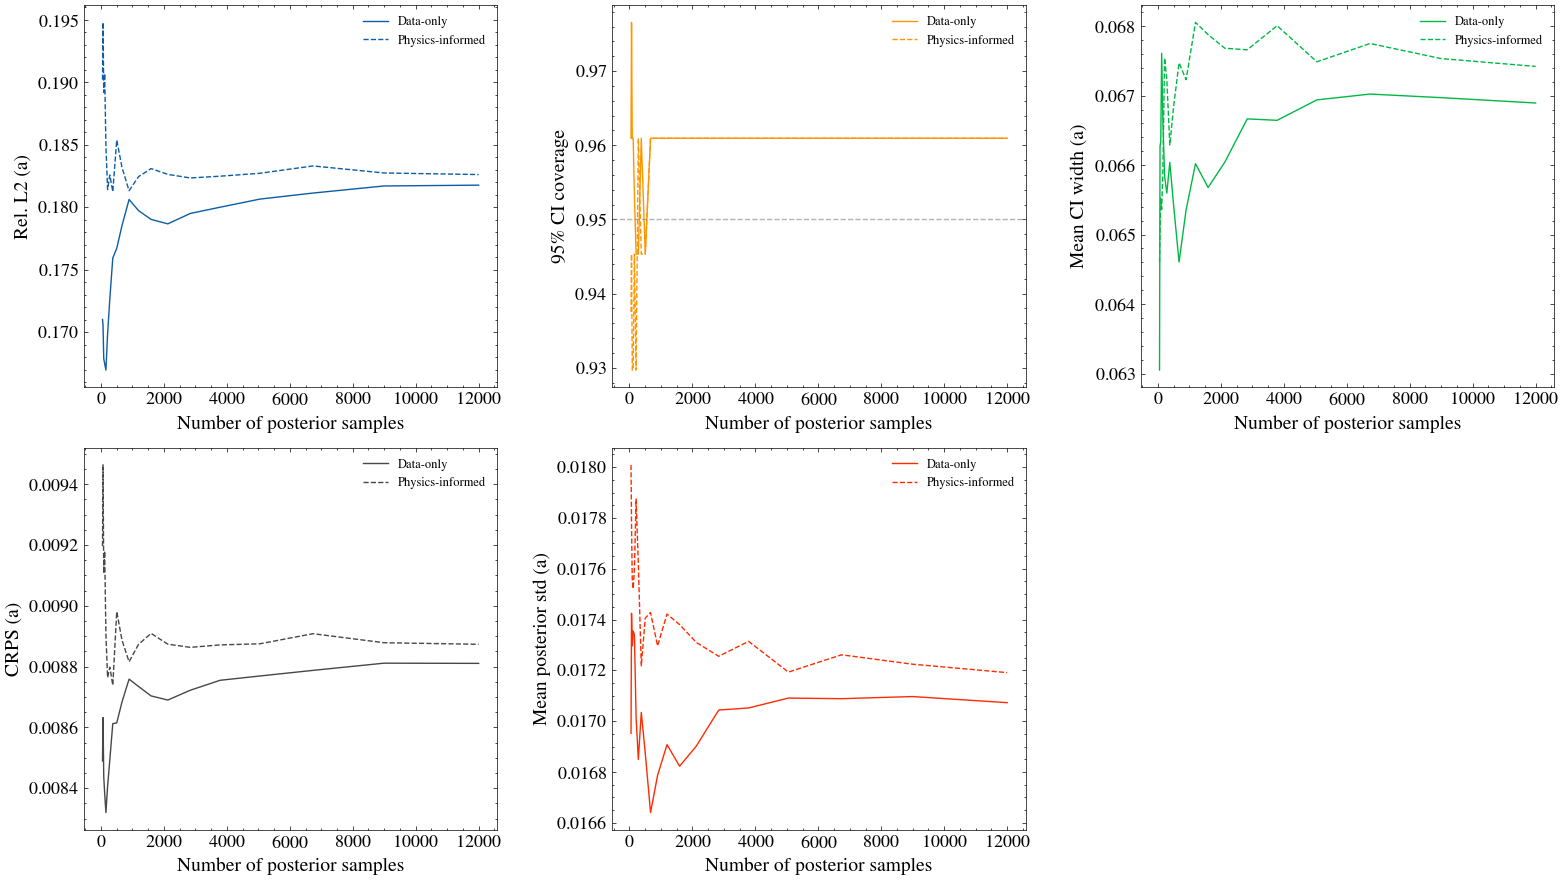

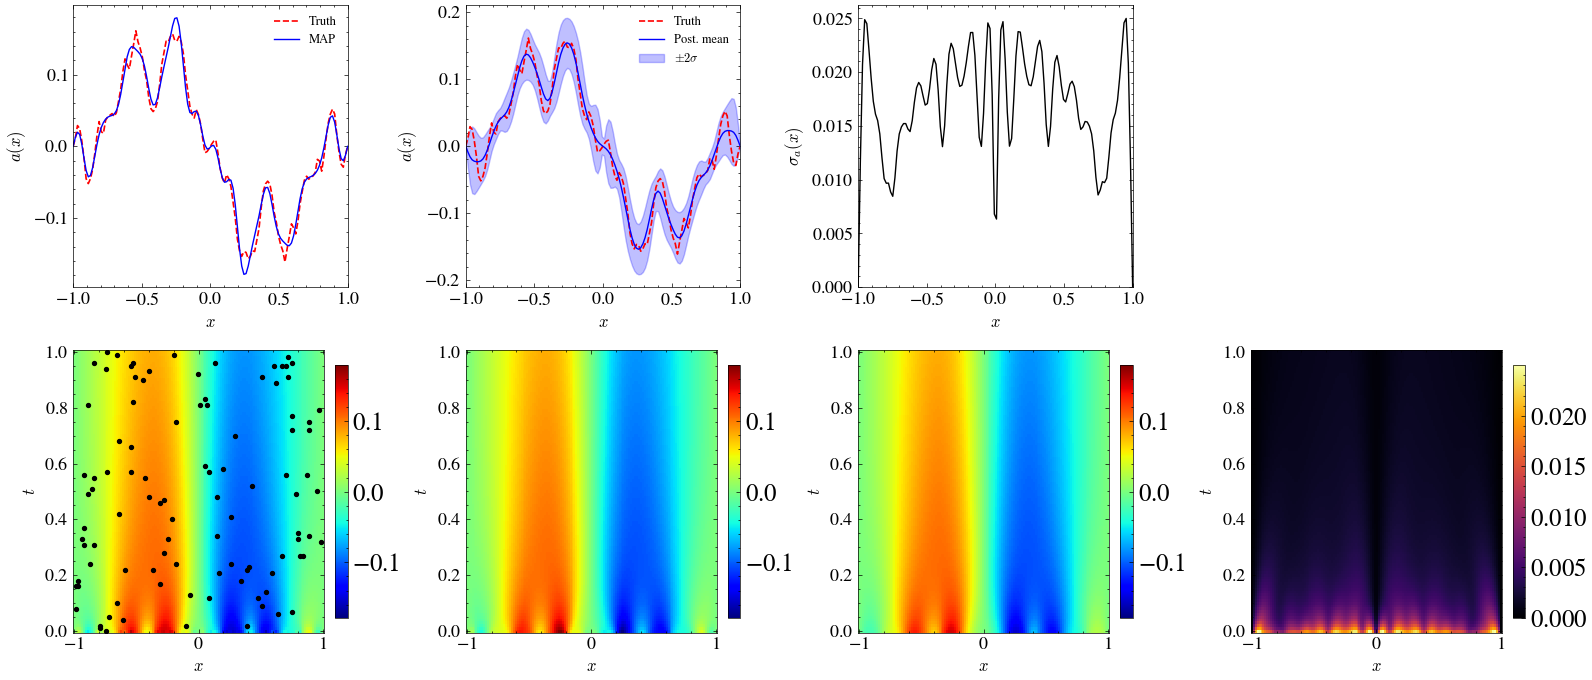

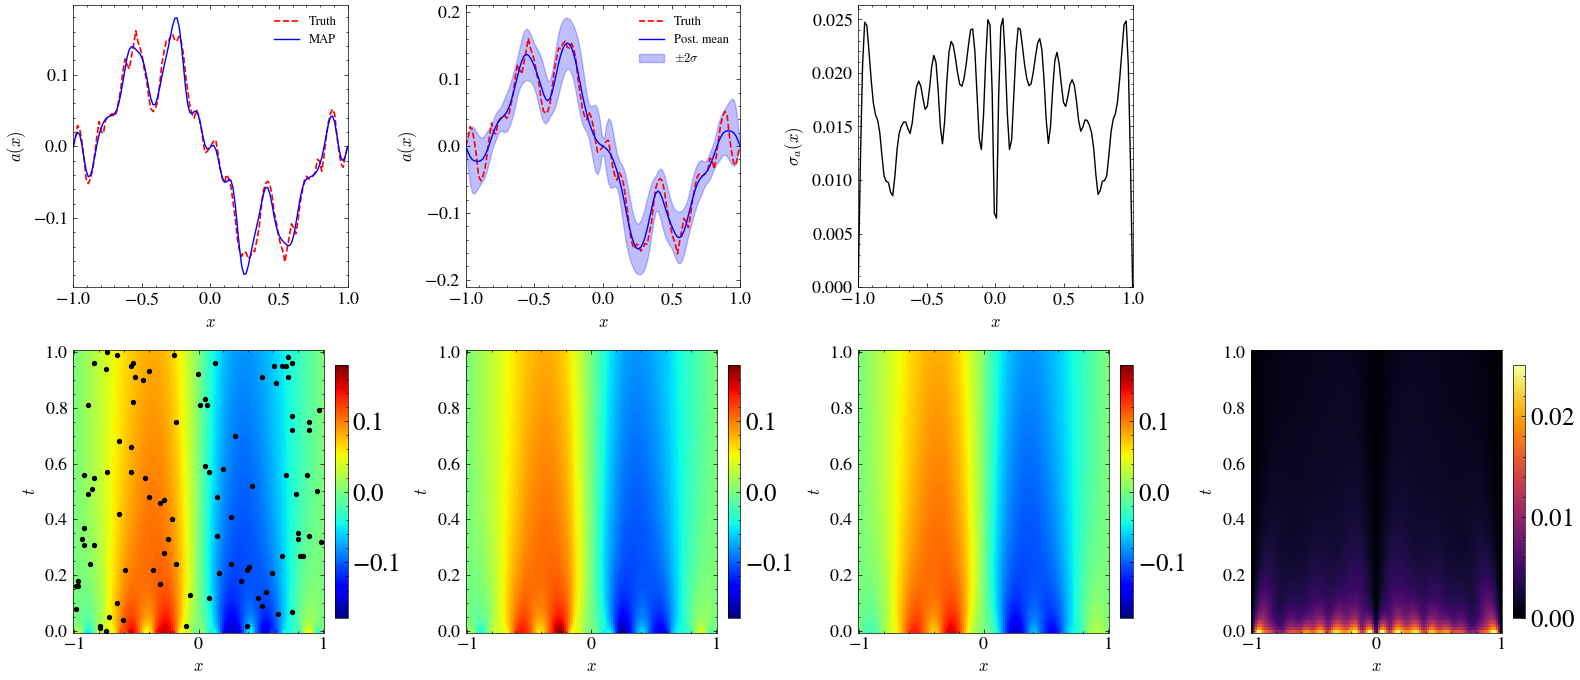

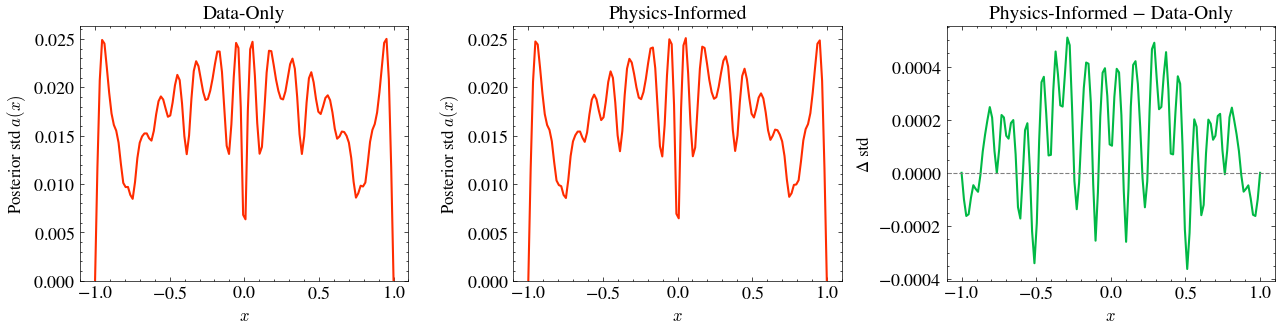

/workspace/experiments/experiment_utils/_plotting.py:576: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.3, facecolor='white', edgecolor='black')


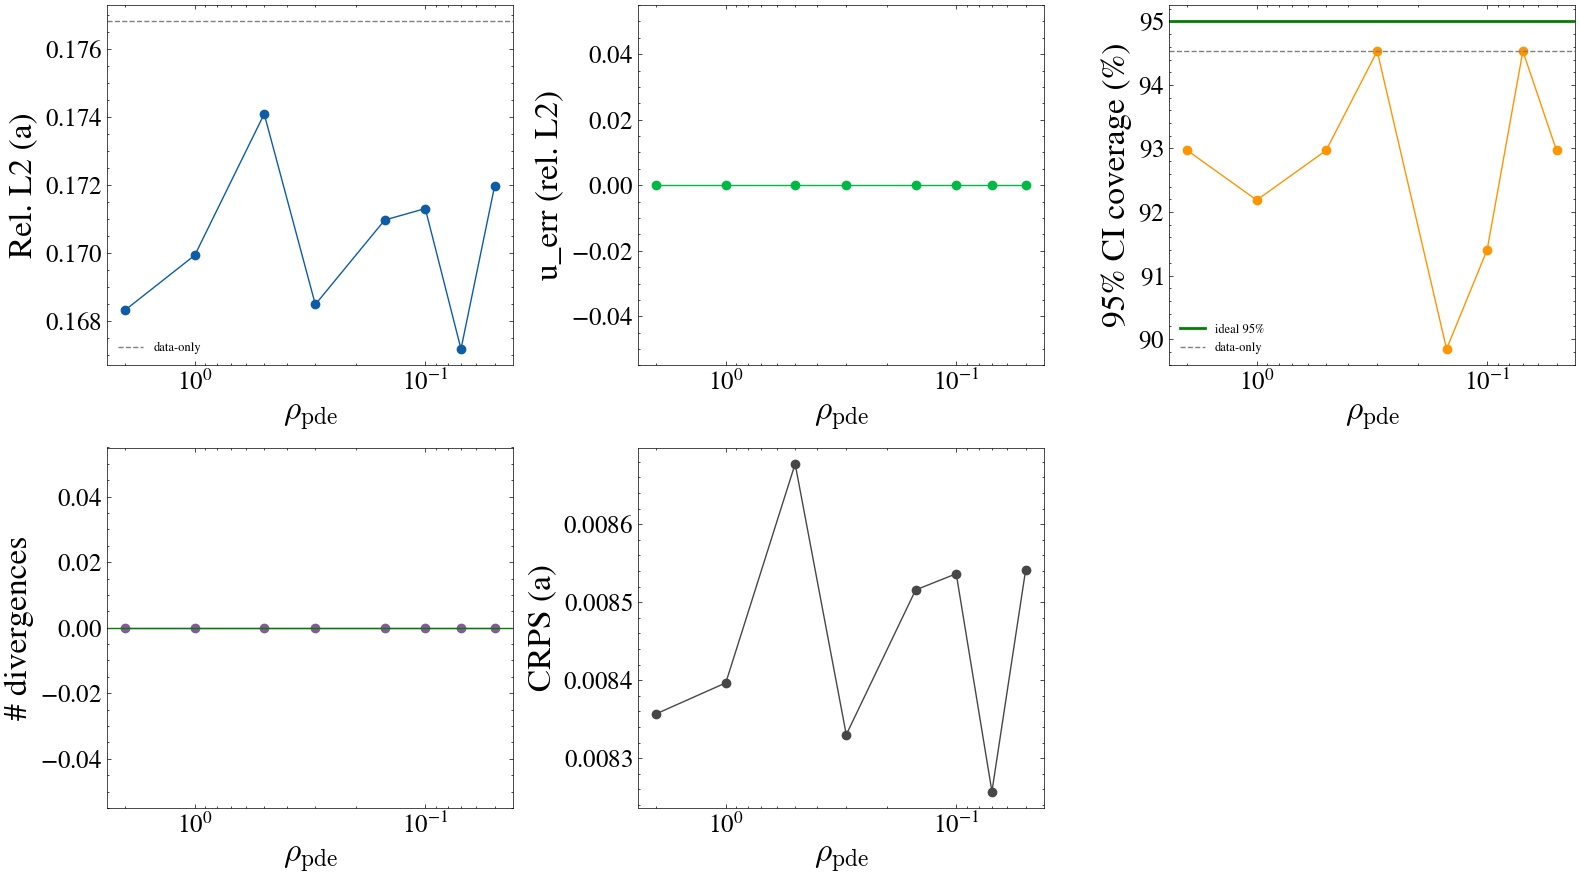

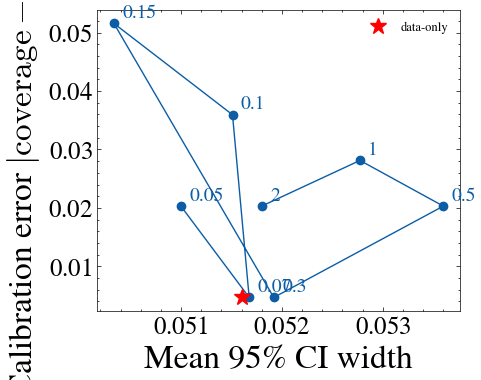

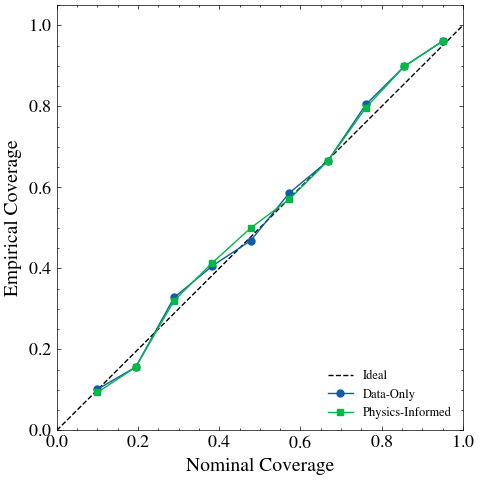

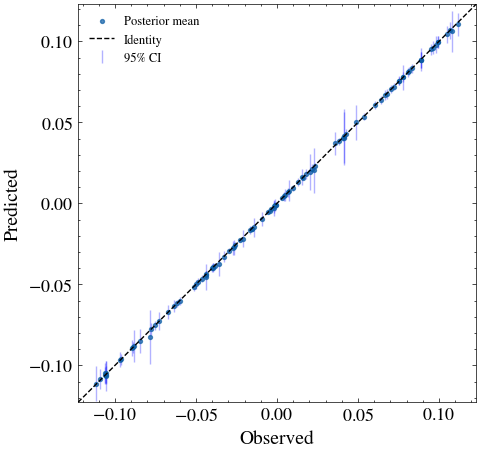

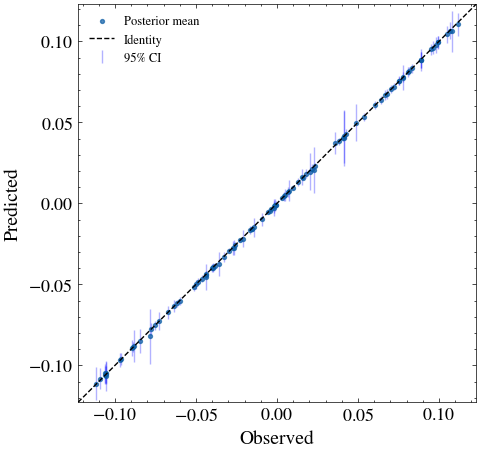

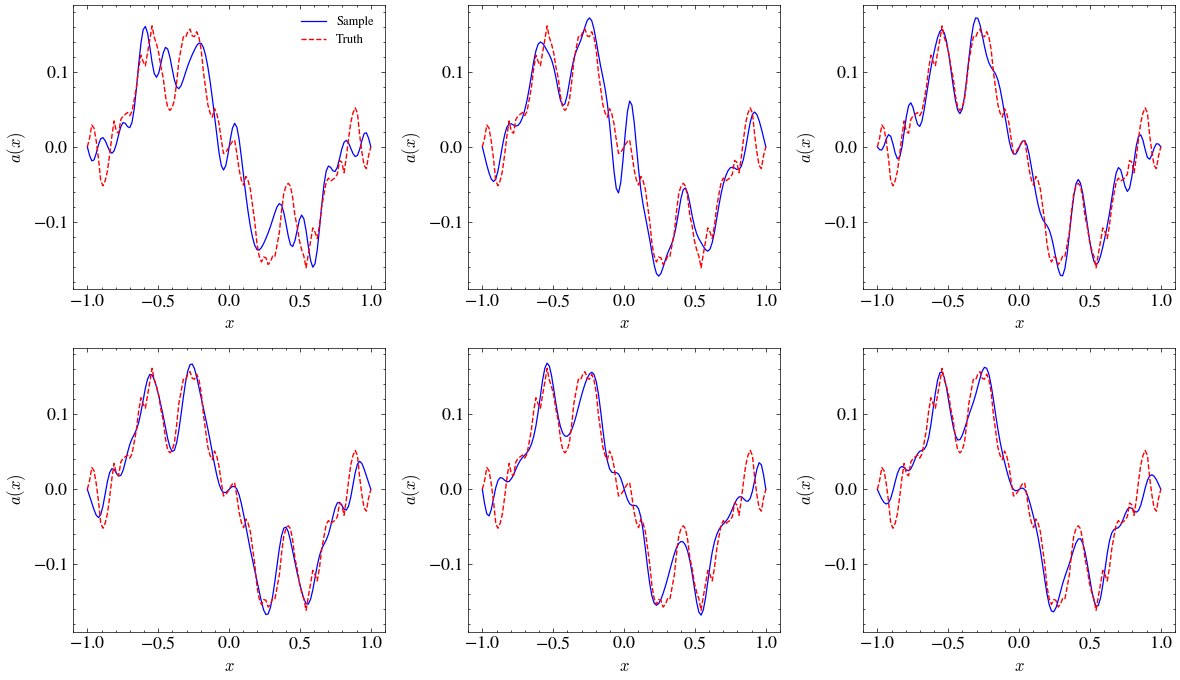

Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0    9968.2    1.0001      0.0010      0.0081
   1    8785.0    1.0004      0.0098      0.0218
   2    9719.0    0.9999      0.0265      0.0133
   3   10082.7    0.9999      0.0476      0.0128
   4   11693.4    1.0000      0.0189      0.0094
   5    8733.0    1.0002      0.0054      0.0109
   6    9587.8    0.9998      0.0193      0.0175
   7   10191.2    0.9999     -0.0556      0.0067
   8    9289.4    1.0003      0.0297      0.0157
   9    9301.1    1.0001      0.0321      0.0124
  10    8930.4    1.0002      0.0436      0.0121
  11   10077.7    0.9999      0.0715      0.0107
  12    9091.2    0.9999      0.0028      0.0131
  13   11231.1    1.0001      0.0274      0.0133
  14   11801.4    1.0002      0.0193      0.0155
  15    9987.2    1.0005      0.0186      0.0186

  RELIABILITY (physics): [PASS] All diagnostics within thresholds
  RELIABILITY (data-only): [PASS] All diagnostics within thresholds


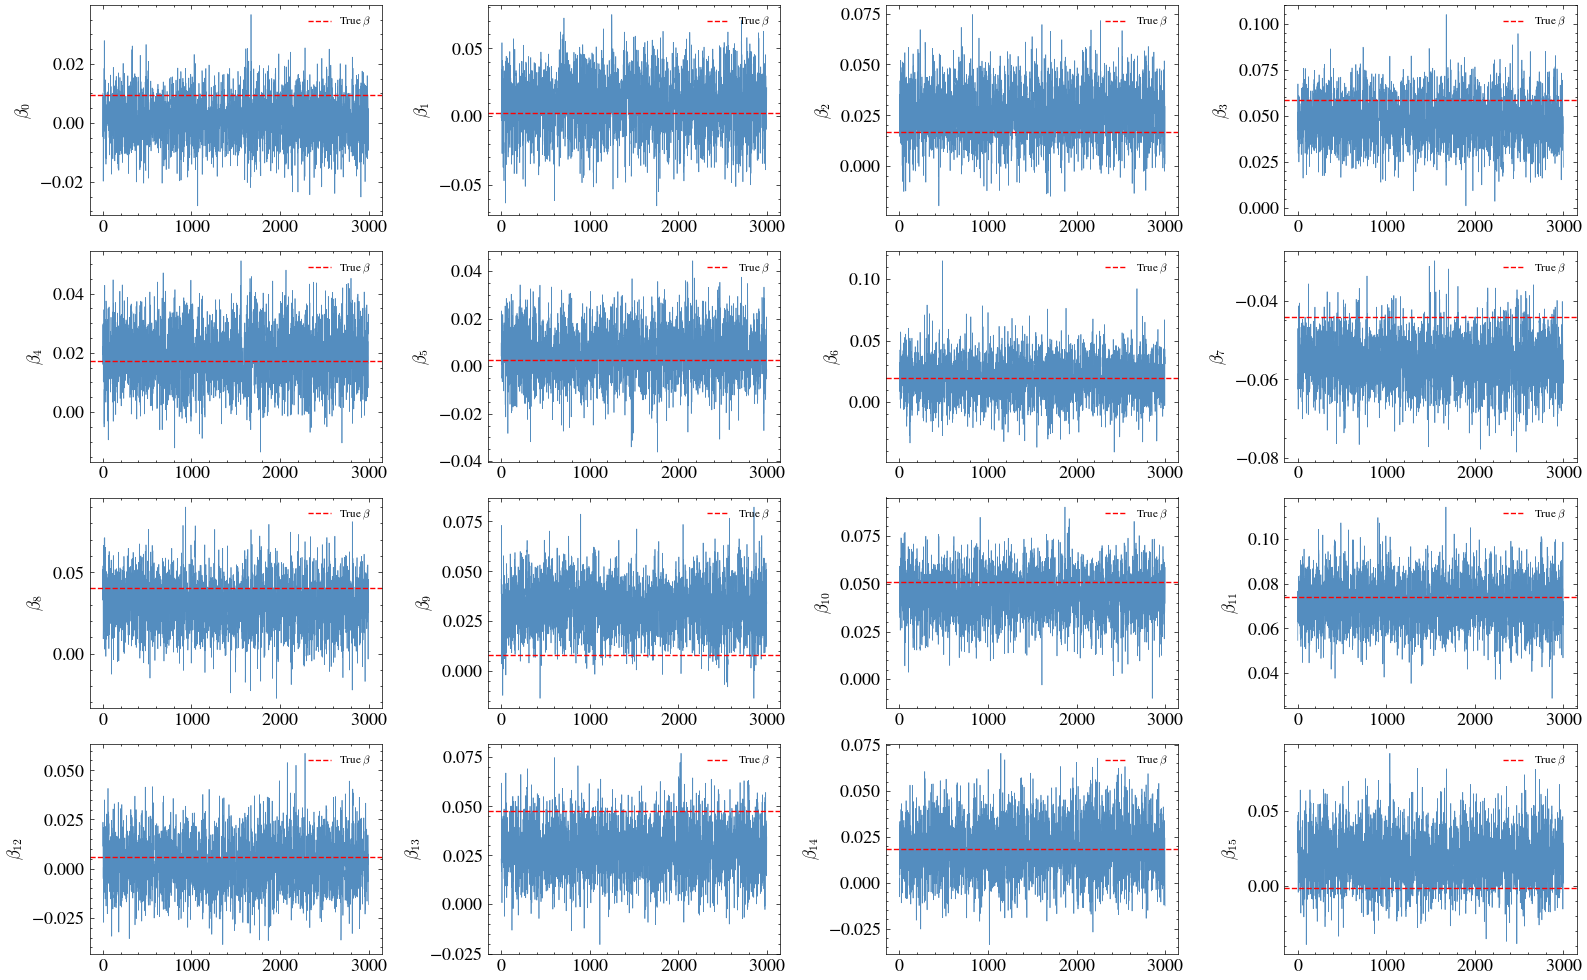

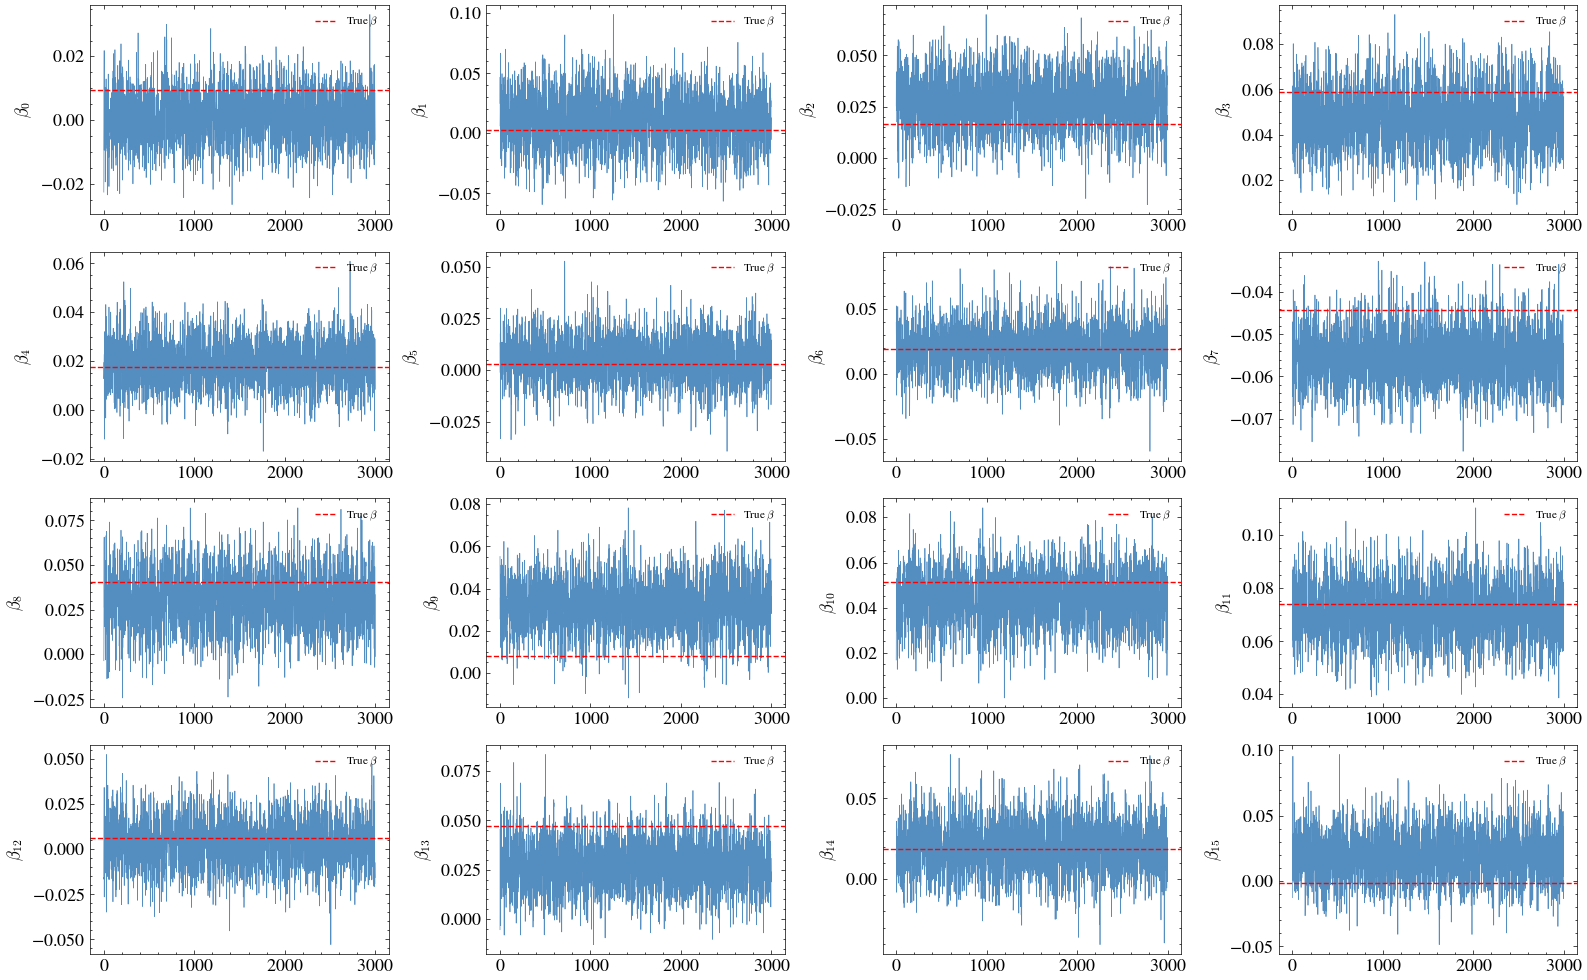

Spearman rho (data-only): 0.347, p = 5.95e-05
Spearman rho (physics): 0.342, p = 7.76e-05


In [13]:
from results_schema import ExperimentResult
from datetime import datetime

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'='*70}")
    print(f"SEED = {SEED}")
    print(f"{'='*70}")

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    FIGURE_DIR = Path(f'figures/physics_burgers/test{TEST_IDX}/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ---- Observations ----
    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX], obs_indices=obs_indices,
    )
    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']
    a_true_np = np.array(a_true[0, :, 0])

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    # ---- Prior Predictive ----
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ---- Build per-seed models ----
    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier_burgers, x_obs, u_obs)
    numpyro_model_data_only = make_numpyro_model(d, log_prior_fn, log_likelihood_fn)
    numpyro_model_physics = make_numpyro_model_physics(d, log_prior_fn, log_likelihood_fn, log_pde_fn)

    # ---- MAP Baseline ----
    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ---- Sigma (tune_sigma) ----
    def _model_factory(sigma):
        def _model():
            numpyro_model_data_only(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        return decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_samples)

    rng, tune_key = random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=SIGMA_CANDIDATES,
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        target_accept_prob=_nuts_cfg_tune['target_accept_prob'],
    )
    print(f"Sigma (tuned): {SIGMA:.6f}")

    # ---- Data-Only MCMC Full Run ----
    print(f"Data-only MCMC: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, sigma={SIGMA}, {NUM_CHAINS} chains ({CHAIN_METHOD})")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc_do, timing_do = run_mcmc(
        numpyro_model_data_only, {"beta": beta_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc_do.print_summary()

    diag_do = extract_mcmc_diagnostics(mcmc_do, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)

    # Decode initial condition and full solution
    a_pred_do = decode_initial_condition_burgers(problem, params, mollifier_burgers, diag_do['samples'])
    u_pred_do = decode_solution_batched(diag_do['samples'], x_full)

    a_do_np = np.array(a_pred_do)
    u_do_np = np.array(u_pred_do[:, :, 0])
    a_std_do = np.std(a_do_np, axis=0)
    u_true_np = np.array(u_true[0, :, 0])

    metrics_do = compute_standard_metrics(a_do_np, a_true_np)
    u_err_do = float(np.linalg.norm(np.mean(u_do_np, axis=0) - u_true_np) / (np.linalg.norm(u_true_np) + 1e-12))

    print(f"Data-only: a_err={metrics_do['a_err']:.4f}  u_err={u_err_do:.4f}  "
          f"coverage={metrics_do['coverage_95']:.2%}  CRPS={metrics_do['crps_a']:.6f}")

    # ---- Physics-Informed Full Run ----
    print(f"Physics MCMC: rho_pde={BEST_RHO_PDE}, {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains")

    rng, mcmc_key_phys = random.split(rng)
    mcmc_phys, timing_phys = run_mcmc(
        numpyro_model_physics, {"beta": beta_mode},
        {"sigma": SIGMA, "rho_pde": BEST_RHO_PDE}, mcmc_key_phys,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    diag_phys = extract_mcmc_diagnostics(mcmc_phys, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)

    a_pred_phys = decode_initial_condition_burgers(problem, params, mollifier_burgers, diag_phys['samples'])
    u_pred_phys = decode_solution_batched(diag_phys['samples'], x_full)

    a_phys_np = np.array(a_pred_phys)
    u_phys_np = np.array(u_pred_phys[:, :, 0])
    a_std_phys = np.std(a_phys_np, axis=0)

    metrics_phys = compute_standard_metrics(a_phys_np, a_true_np)
    u_err_phys = float(np.linalg.norm(np.mean(u_phys_np, axis=0) - u_true_np) / (np.linalg.norm(u_true_np) + 1e-12))

    print(f"Physics: a_err={metrics_phys['a_err']:.4f}  u_err={u_err_phys:.4f}  "
          f"coverage={metrics_phys['coverage_95']:.2%}  CRPS={metrics_phys['crps_a']:.6f}")

    # ---- Chi2 PPC ----
    u_obs_np = np.array(u_obs[0, :, 0])
    u_pred_at_obs_do = u_do_np[:, np.array(obs_indices)]
    u_pred_at_obs_phys = u_phys_np[:, np.array(obs_indices)]
    chi2_do, pval_do = chi2_ppc(u_obs_np, u_pred_at_obs_do, SIGMA)
    chi2_phys, pval_phys = chi2_ppc(u_obs_np, u_pred_at_obs_phys, SIGMA)
    print(f"  Chi2 PPC (data-only): chi2={chi2_do:.2f}, p={pval_do:.4f}")
    print(f"  Chi2 PPC (physics):   chi2={chi2_phys:.2f}, p={pval_phys:.4f}")

    # ---- Spearman error-std correlation ----
    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, np.mean(a_do_np, axis=0), a_std_do)
    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, np.mean(a_phys_np, axis=0), a_std_phys)

    # ---- Save Results ----
    sharpness_do = float(np.mean(a_std_do))
    sharpness_phys = float(np.mean(a_std_phys))

    do_result = {
        "sigma": SIGMA, "label": "data_only",
        "ess_min": diag_do['ess_min'], "rhat_max": diag_do['rhat_max'],
        "rhat_mean": diag_do['rhat_mean'], "n_div": diag_do['n_div'],
        "reliability_flag": diag_do['flag'],
        "reliability_explanation": diag_do['flag_explanation'],
        "a_err": metrics_do['a_err'], "u_err": u_err_do,
        "crps_a": metrics_do['crps_a'], "nll_a": metrics_do['nll_a'],
        "coverage": metrics_do['coverage_95'],
        "ci_width": metrics_do['ci_width'], "mean_std": sharpness_do,
        "cal_levels": metrics_do['cal_levels'],
        "cal_empirical": metrics_do['cal_empirical'],
        "chi2_ppc": chi2_do, "chi2_ppc_pvalue": pval_do,
        "map_a_err": float(rmse_map_a), "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": float(spearman_rho_do),
        "spearman_pvalue_error_std": float(spearman_p_do),
        "warmup_time_s": timing_do['warmup_time_s'],
        "sampling_time_s": timing_do['sampling_time_s'],
        "step_time_s": timing_do['step_time_s'],
    }

    phys_result = {
        "sigma": SIGMA, "label": "physics",
        "ess_min": diag_phys['ess_min'], "rhat_max": diag_phys['rhat_max'],
        "rhat_mean": diag_phys['rhat_mean'], "n_div": diag_phys['n_div'],
        "reliability_flag": diag_phys['flag'],
        "reliability_explanation": diag_phys['flag_explanation'],
        "a_err": metrics_phys['a_err'], "u_err": u_err_phys,
        "crps_a": metrics_phys['crps_a'], "nll_a": metrics_phys['nll_a'],
        "coverage": metrics_phys['coverage_95'],
        "ci_width": metrics_phys['ci_width'], "mean_std": sharpness_phys,
        "cal_levels": metrics_phys['cal_levels'],
        "cal_empirical": metrics_phys['cal_empirical'],
        "chi2_ppc": chi2_phys, "chi2_ppc_pvalue": pval_phys,
        "map_a_err": float(rmse_map_a), "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": float(spearman_rho_phys),
        "spearman_pvalue_error_std": float(spearman_p_phys),
        "warmup_time_s": timing_phys['warmup_time_s'],
        "sampling_time_s": timing_phys['sampling_time_s'],
        "step_time_s": timing_phys['step_time_s'],
    }

    experiment = ExperimentResult(
        experiment="physics",
        problem="burgers",
        experiment_type="comparison",
        seed=SEED,
        test_idx=TEST_IDX,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        conditions={
            "data_only": build_mcmc_result(do_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
            "physics": build_mcmc_result(phys_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS),
        },
        prior=build_prior_result(prior_metrics),
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ---- Plots ----
    x_mesh_np = np.array(x_mesh)

    plot_metrics_comparison_table(
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_do_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_do['a_err'],
            'Rel. L2 (u)': u_err_do,
            'CRPS (a)': metrics_do['crps_a'],
            '95% Coverage': metrics_do['coverage_95'],
            'CI Width (a)': metrics_do['ci_width'],
            'Sharpness (mean std)': sharpness_do,
            'ESS min': diag_do['ess_min'],
            'Divergences': diag_do['n_div'],
        },
        {
            'RMSE (a)': float(rmse(jnp.array(np.mean(a_phys_np, axis=0)), jnp.array(a_true_np))),
            'Rel. L2 (a)': metrics_phys['a_err'],
            'Rel. L2 (u)': u_err_phys,
            'CRPS (a)': metrics_phys['crps_a'],
            '95% Coverage': metrics_phys['coverage_95'],
            'CI Width (a)': metrics_phys['ci_width'],
            'Sharpness (mean std)': sharpness_phys,
            'ESS min': diag_phys['ess_min'],
            'Divergences': diag_phys['n_div'],
        },
        title=f'Burgers seed={SEED} (sigma={SIGMA}, rho_pde={BEST_RHO_PDE})',
    )

    # Significance Tests
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))
    def _coverage_95(s, t):
        _, emp = compute_calibration(s, t, np.array([0.95]))
        return float(emp[0])
    def _ci_width(s, t): return ci_width_95(s)

    rng_bs = np.random.default_rng(2)
    diff_crps_a = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _crps_a, rng=rng_bs)
    diff_cov = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _coverage_95, rng=rng_bs)
    diff_width = bootstrap_metric_difference_ci(a_do_np, a_phys_np, a_true_np, _ci_width, rng=rng_bs)

    format_significance_table({
        'CRPS (a) diff (DO - Phys)': diff_crps_a,
        'Coverage 95% diff (DO - Phys)': diff_cov,
        'CI Width diff (DO - Phys)': diff_width,
    }, title=f'Burgers seed={SEED} -- RQ2: Physics vs Data-Only (Bootstrap)')

    # Metric Convergence
    conv_do = compute_metric_convergence(a_do_np, a_true_np)
    conv_phys = compute_metric_convergence(a_phys_np, a_true_np)
    plot_metric_convergence(
        [conv_do, conv_phys],
        labels=['Data-only', 'Physics-informed'],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # Field plots
    plot_burgers_field_comparison(
        x_mesh=x_mesh_np, t_mesh=t_mesh,
        a_true=a_true_np,
        a_map=np.array(a_map[:, 0]),
        a_mean=a_do_np.mean(axis=0),
        a_std=a_std_do,
        u_true=u_true_np,
        u_map=np.array(u_map[:, 0]),
        u_mean=u_do_np.mean(axis=0),
        u_std=np.std(u_do_np, axis=0),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison_data_only.png',
    )

    plot_burgers_field_comparison(
        x_mesh=x_mesh_np, t_mesh=t_mesh,
        a_true=a_true_np,
        a_map=np.array(a_map[:, 0]),
        a_mean=a_phys_np.mean(axis=0),
        a_std=a_std_phys,
        u_true=u_true_np,
        u_map=np.array(u_map[:, 0]),
        u_mean=u_phys_np.mean(axis=0),
        u_std=np.std(u_phys_np, axis=0),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison_physics.png',
    )

    plot_burgers_std_comparison(
        x_mesh=x_mesh_np,
        std_a=a_std_do,
        std_b=a_std_phys,
        label_a='Data-Only',
        label_b='Physics-Informed',
        save_path=FIGURE_DIR / 'std_comparison.png',
    )

    plot_rho_sweep(
        sweep_results, _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'rho_sweep.png',
    )

    plot_sharpness_calibration_tradeoff(
        sweep_results, _sweep_data_only_baseline,
        save_path=FIGURE_DIR / 'sharpness_calibration_tradeoff.png',
    )

    plot_calibration_overlay([
        (metrics_do['cal_levels'], metrics_do['cal_empirical'], 'Data-Only'),
        (metrics_phys['cal_levels'], metrics_phys['cal_empirical'], 'Physics-Informed'),
    ], save_path=FIGURE_DIR / 'calibration_overlay.png')

    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs_do,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive_data_only.png',
    )
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs_phys,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive_physics.png',
    )

    plot_burgers_posterior_gallery(
        x_mesh=x_mesh_np, a_samples=a_phys_np,
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    # Diagnostics
    print_dimension_diagnostics(np.array(diag_phys['samples']), diag_phys['ess'], diag_phys['rhat'])
    print(f"\n  RELIABILITY (physics): [{diag_phys['flag']}] {diag_phys['flag_explanation']}")
    print(f"  RELIABILITY (data-only): [{diag_do['flag']}] {diag_do['flag_explanation']}")

    beta_true_np = np.array(beta_true)
    beta_all_chains_do = np.array(mcmc_do.get_samples(group_by_chain=True)["beta"])
    plot_trace(beta_all_chains_do[0], beta_true_np, num_warmup=0,
               save_path=FIGURE_DIR / 'trace_plots_data_only.png')

    beta_phys_by_chain = np.array(mcmc_phys.get_samples(group_by_chain=True)["beta"])
    plot_trace(beta_phys_by_chain[0], beta_true_np, num_warmup=0,
               save_path=FIGURE_DIR / 'trace_plots_physics.png')

    spearman_rho_do, spearman_p_do = compute_error_std_correlation(
        a_true_np, np.mean(a_do_np, axis=0), a_std_do,
        save_path=FIGURE_DIR / 'error_vs_std_data_only.png',
    )
    print(f'Spearman rho (data-only): {spearman_rho_do:.3f}, p = {spearman_p_do:.2e}')

    spearman_rho_phys, spearman_p_phys = compute_error_std_correlation(
        a_true_np, np.mean(a_phys_np, axis=0), a_std_phys,
        save_path=FIGURE_DIR / 'error_vs_std_physics.png',
    )
    print(f'Spearman rho (physics): {spearman_rho_phys:.3f}, p = {spearman_p_phys:.2e}')

## Cross-Seed Aggregation Summary

In [14]:
results = load_cross_seed_results("physics", "burgers")
if len(results) > 1:
    print(f"Cross-Seed Summary ({len(results)} seeds: {[r.seed for r in results]})")
    for cond in list(results[0].conditions.keys()):
        print(f"\n--- {cond} ---")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in ["a_err", "u_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]:
            try:
                s = cross_seed_metric_summary(results, metric=m, condition_key=cond)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Summary (17 seeds: [7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123])

--- data_only ---
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.1228      0.0601      0.0663      0.2302
u_err                 0.0268      0.0107      0.0159      0.0494
crps_a                0.0089      0.0027      0.0042      0.0118
nll_a                -3.0537      0.3324     -3.6764     -2.6866
coverage_95           0.9274      0.0309      0.8828      0.9609
ci_width              0.0629      0.0143      0.0350      0.0800
mean_std              0.0161      0.0037      0.0089      0.0204
ess_min            6094.3424   1415.1832   4803.3912   9180.5532
rhat_max              1.0008      0.0004      1.0004      1.0018
n_div                 0.0000      0.0000      0.0000      0.0000

--- physics ---
Metric                  Mean         Std         Min         Max
--------------------